# Geospatial Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_parquet("../data/processed/taxi_trip_cleaned.parquet")

## Pickup demand

In [4]:
pickup_demand = (
    df.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

display(pickup_demand.head(20))

,PULocationID,trip_count
233,237,160343
232,236,153640
128,132,152589
157,161,146641
182,186,110700
138,142,110004
158,162,108703
226,230,106114
78,79,100998
235,239,97465


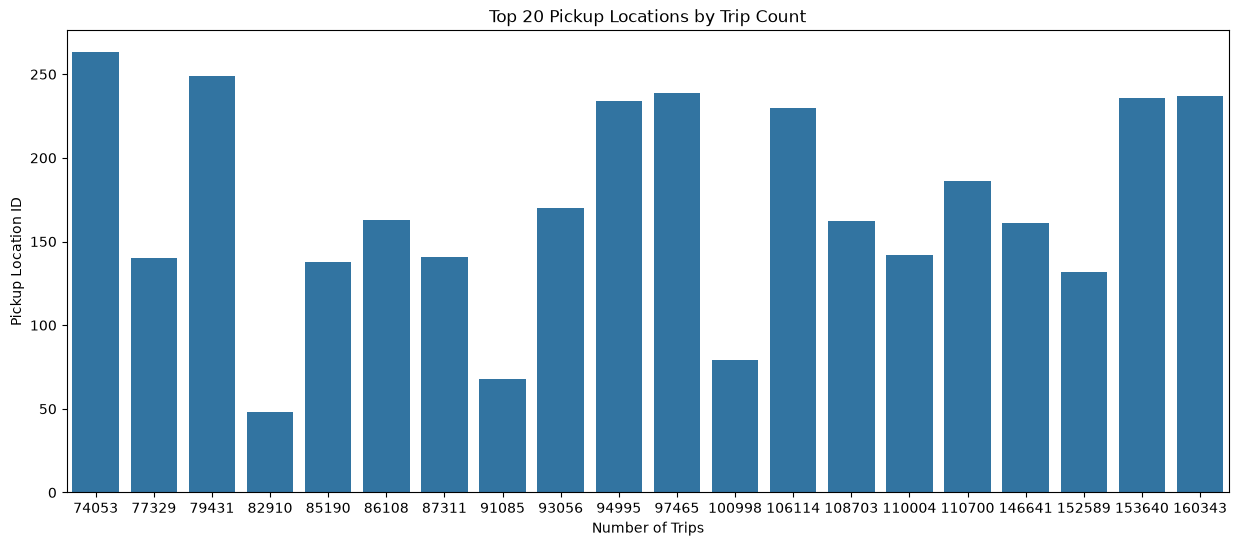

In [9]:
top_pickups = pickup_demand.head(20)

plt.figure(figsize=(15, 6))

sns.barplot(
    data=top_pickups,
    x="trip_count",
    y="PULocationID"
)

plt.title("Top 20 Pickup Locations by Trip Count")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Location ID")

plt.show()

## Drop-off demand

In [10]:
dropoff_demand = (
    df.groupby("DOLocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

display(dropoff_demand.head(20))

,DOLocationID,trip_count
230,236,156661
231,237,146726
156,161,121571
165,170,99583
224,230,99157
137,142,97680
233,239,97287
136,141,95943
67,68,90437
157,162,89412


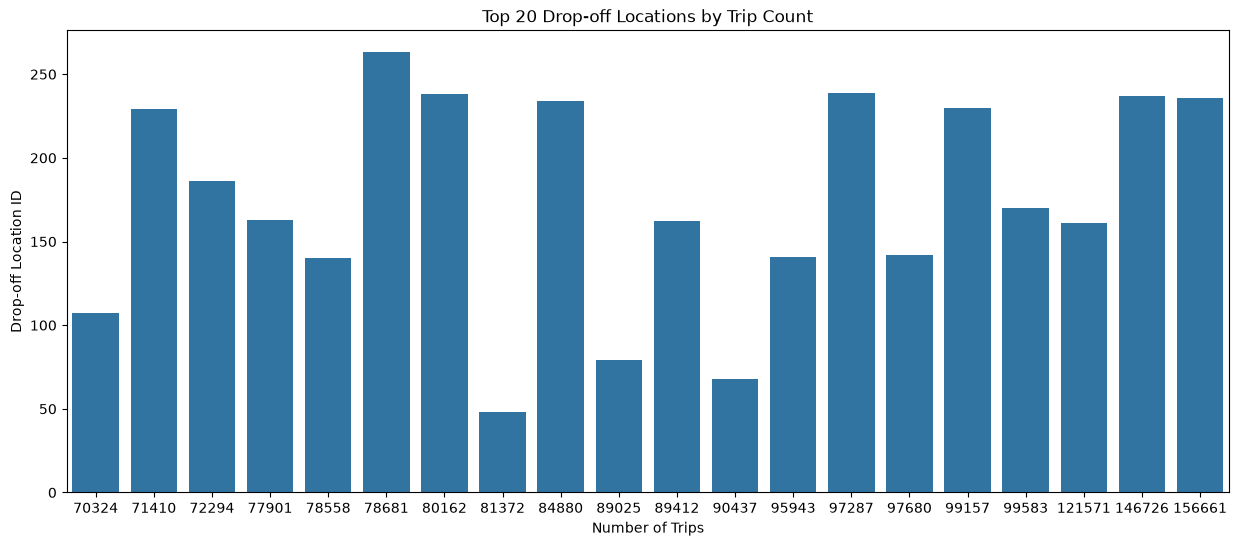

In [12]:
top_dropoffs = dropoff_demand.head(20)

plt.figure(figsize=(15, 6))

sns.barplot(
    data=top_dropoffs,
    x="trip_count",
    y="DOLocationID"
)

plt.title("Top 20 Drop-off Locations by Trip Count")
plt.xlabel("Number of Trips")
plt.ylabel("Drop-off Location ID")

plt.show()

## Pickup vs Drop-off demand

In [13]:
location_activity = (
    df.groupby("PULocationID")
    .size()
    .reset_index(name="pickup_count")
)

dropoff_counts = (
    df.groupby("DOLocationID")
    .size()
    .reset_index(name="dropoff_count")
)

location_activity = location_activity.rename(
    columns={"PULocationID": "LocationID"}
)

dropoff_counts = dropoff_counts.rename(
    columns={"DOLocationID": "LocationID"}
)

location_activity = location_activity.merge(
    dropoff_counts,
    on="LocationID",
    how="outer"
).fillna(0)

display(location_activity.head())

,LocationID,pickup_count,dropoff_count
0,1,486,5986.0
1,2,3,12.0
2,3,491,815.0
3,4,16613,20776.0
4,5,4,14.0


In [14]:
location_activity["total_activity"] = (
    location_activity["pickup_count"] +
    location_activity["dropoff_count"]
)

display(
    location_activity.sort_values(
        "total_activity",
        ascending=False
    ).head(20)
)

,LocationID,pickup_count,dropoff_count,total_activity
232,236,153640,156661.0,310301.0
233,237,160343,146726.0,307069.0
157,161,146641,121571.0,268212.0
138,142,110004,97680.0,207684.0
226,230,106114,99157.0,205271.0
158,162,108703,89412.0,198115.0
235,239,97465,97287.0,194752.0
166,170,93056,99583.0,192639.0
78,79,100998,89025.0,190023.0
137,141,87311,95943.0,183254.0


## Most common routes

In [15]:
routes = (
    df.groupby(
        ["PULocationID", "DOLocationID"]
    )
    .size()
    .reset_index(name="trip_count")
    .sort_values(
        "trip_count",
        ascending=False
    )
)

display(routes.head(20))

,PULocationID,DOLocationID,trip_count
35787,237,236,24197
35554,236,237,21055
35553,236,236,17344
35788,237,237,16185
23903,161,237,10380
35719,237,161,9541
20903,142,239,9065
36226,239,238,8919
36149,239,142,8622
23902,161,236,8573


## Route-level economics

In [17]:
route_summary = (
    df.groupby(
        ["PULocationID", "DOLocationID"]
    )
    .agg(
        trip_count=("trip_distance", "size"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median"),
        median_fare=("fare_amount", "median"),
        median_total_amt=("total_amount", "median")
    )
    .reset_index()
    .sort_values(
        "trip_count",
        ascending=False
    )
)

display(route_summary.head(20))

,PULocationID,DOLocationID,trip_count,median_distance,median_duration,median_fare,median_total_amt
35787,237,236,24197,1.000,6.800000,8.6,15.480
35554,236,237,21055,0.980,7.816667,9.3,16.250
35553,236,236,17344,0.540,4.283333,6.5,12.740
35788,237,237,16185,0.570,4.750000,6.5,13.440
23903,161,237,10380,1.010,8.666667,10.0,17.940
35719,237,161,9541,1.010,8.533333,10.0,17.340
20903,142,239,9065,0.940,5.900000,7.9,15.000
36226,239,238,8919,0.800,4.900000,7.2,13.700
36149,239,142,8622,0.820,5.816667,7.9,14.340
23902,161,236,8573,1.840,12.666667,13.5,22.750


## Average distance by pickup location

In [18]:
pickup_stats = (
    df.groupby("PULocationID")
    .agg(
        trip_count=("trip_distance", "size"),
        median_distance=("trip_distance", "median"),
        median_fare=("fare_amount", "median"),
        median_duration=("trip_duration_minutes", "median")
    )
    .reset_index()
)

display(
    pickup_stats
    .sort_values("trip_count", ascending=False)
    .head(20)
)

,PULocationID,trip_count,median_distance,median_fare,median_duration
233,237,160343,1.20,10.700,9.500000
232,236,153640,1.39,11.400,10.183333
128,132,152589,16.80,70.000,36.333333
157,161,146641,1.50,13.500,12.700000
182,186,110700,1.49,13.580,13.416667
138,142,110004,1.60,12.100,10.666667
158,162,108703,1.50,13.500,12.400000
226,230,106114,1.54,14.200,12.816667
78,79,100998,1.74,14.900,12.133333
235,239,97465,1.60,12.800,10.616667


## Location × time

In [19]:
location_hour = (
    df.groupby(
        ["PULocationID", "pickup_hour"]
    )
    .size()
    .reset_index(name="trip_count")
)

In [20]:
busiest_location_by_hour = (
    location_hour
    .loc[
        location_hour.groupby("pickup_hour")["trip_count"]
        .idxmax()
    ]
    .sort_values("pickup_hour")
)

display(busiest_location_by_hour)

,PULocationID,pickup_hour,trip_count
1746,79,0,8040
1747,79,1,7398
1748,79,2,5774
1749,79,3,4017
1750,79,4,2033
2827,132,5,2834
2828,132,6,4258
5170,236,7,5825
5171,236,8,8360
5172,236,9,8845
